# Mission Laika: Satellite connection back online

The following exercises are a part of *Mission LAIKA: a set of case studies on Linear Algebra in Kinematics and Aerodynamics*. 

You can refer to Brightspace for more details on the case studies in Mission LAIKA.

In the lesson slides is a recap of the example you saw in the lecture.

Run the following code to import the necessary libraries that will be used throughout this notebook.

In [ ]:
# If you are having problems with the imports, uncomment the following code to install necessary libraries.
# %pip install numpy
# %pip install matplotlib
# ! pip install tabulate

import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
import json
import requests

Due to a collision with space debris, the trajectory of a satellite has been altered. 

<img src="images/orbit.png" 
        alt="Comet" 
        width=50%
        style="display: block; margin: 0 auto" />


To understand its movement, we need to determine its new orbit. We know the orbit will be one of three types:

- parabolic
- elliptical
- hyperbolic

The trajectory of the satellite can be described by a polar equation:
<img src="images/orbit_eq.png" 
        alt="Comet" 
        width=20%
        style="float: right; margin-left: 30px; margin-right: 40px" />
        
$r = b + e(r cos(\theta))$
    

- $r$ is the distance from the centre of attraction, in thousands of kilometers
- $\theta$ is the angular position
- $b$ and $e$ define the shape and characteristics of the orbit, which are currently unknown

Using observational data for $r$ and $\theta$, we can apply linear regression to estimate $b$ and $e$. With these approximations, we can determine whether the satellite's new path is parabolic, elliptical, or hyperbolic, and better predict its future trajectory.

The code below contains the position data of the satellite from after collision with the space debris.

In [ ]:
url = "https://raw.githubusercontent.com/PRIME-TU-Delft/MissionLAIKA/main/PythonExercises/CaseStudy15/orbit_params.txt"

response = requests.get(url)
response.raise_for_status()
state = json.loads(response.text)

b = state["b"]
e = state["e"]
seed = state["seed"]

theta = np.array([0.88,1.1,1.42,1.77,2.14])
rng = np.random.default_rng(seed=seed)
r = rng.normal(0,0.05,5) + b / ( 1 - e * np.cos(theta))
theta += rng.normal(0,0.05,5)

table = [['r'] + list(r), ['theta'] + list(theta)]
print(tabulate(table, tablefmt="grid"))

+-------+----------+---------+---------+---------+---------+
| r     | 2.84125  | 2.31986 | 1.69215 | 1.27034 | 1.15597 |
+-------+----------+---------+---------+---------+---------+
| theta | 0.832556 | 1.07905 | 1.49232 | 1.73125 | 2.14758 |
+-------+----------+---------+---------+---------+---------+


We want to determine the parameters $b$ and $e$ for the new orbit of the satellite.

First determine the design matrix for this problem. Replace ``None`` with your solution.

In [14]:
coeff = r * np.cos(theta)
A = np.array([[1.00, coeff[0]],
            [1.00, coeff[1]],
            [1.00, coeff[2]],
            [1.00, coeff[3]],
            [1.00, coeff[4]]])

assert A.shape == (5,2), "incorrect shape"
np.testing.assert_allclose(A, np.array(state["A_ans"]), err_msg="A is not correctly calculated")

Secondly, determine the obsevation vector.

In [15]:
observation_vector = r.copy()

assert len(observation_vector) == 5, "incorrect shape"

From the previous questions we find that the least squares problem for this exercise has the normal equation form: $$C \begin{pmatrix} b \\ e \end{pmatrix} = \textbf{z}$$

Determine $C$ and $\textbf{z}$.

In [16]:
C = A.T @ A

z = A.T @ observation_vector

print(f"C is equal to {C}")
print(f"z is equal to {z}")

assert C.shape == (2,2), "incorrect shape"
np.testing.assert_allclose(C, np.array(state["C_ans"]), err_msg="C is not correctly calculated")

assert len(z) == 2, "incorrect shape"
np.testing.assert_allclose(z, np.array(state["z_ans"]), err_msg="z is not correctly calculated")

C is equal to [[5.         2.30680956]
 [2.30680956 5.31223572]]
z is equal to [9.27958936 7.21188322]


Calculate the least squares estimate of the vector $\begin{pmatrix} b \\ e \end{pmatrix}$

In [17]:
estimate = np.linalg.solve(C,z)
b_estimate = estimate[0]
e_estimate = estimate[1]

assert len(estimate) == 2, "incorrect shape"

assert np.isclose(estimate[0],b,rtol=0.15), "your least squares estimate for b is likely incorrect"
print(f"Least squares estimate for b: {b}")

assert np.isclose(estimate[1],e,rtol=0.15), "your least squares estimate for e is likely incorrect"
print(f"Least squares estimate for e: {e}")

Least squares estimate for b: 1.5
Least squares estimate for e: 0.75


Complete the following code to classify the orbit of the satellite based on the LAIKA slide from the lecture on how the parameter $e$ is linked to the orbit type. 

**Hint: Recall that the orbit is an ellipse if $0 \leq e < 1$, parabola if $e = 1$, and hyperbola if $e > 1$.**
<img src="images/orbit_types.png" 
        alt="Comet" 
        width=50%
        style="display: block; margin: 0 auto" />

What type of orbit does the satellite have after the collision?

**Hint: You can use [`if` statements](https://docs.python.org/3/tutorial/controlflow.html) to select the correct orbit type.**

In [18]:
def find_orbit(e_value):

    orbit = None
    # classify your orbit based on e_value
    if e_value >= 0 and e_value < 1:
        orbit = "ellipse"
    elif e_value == 1:
        orbit = "parabola"
    else:
        orbit = "hyperbola"

    return orbit

orbit_value = find_orbit(e_estimate)
orbit_value

'ellipse'

Finally, give an explicit expression for the distance $r$ of the satellite to the origin (center).

Here $r (\theta)$ will be a function of the angle $\theta$ and use your estimates for $b$ and $e$.

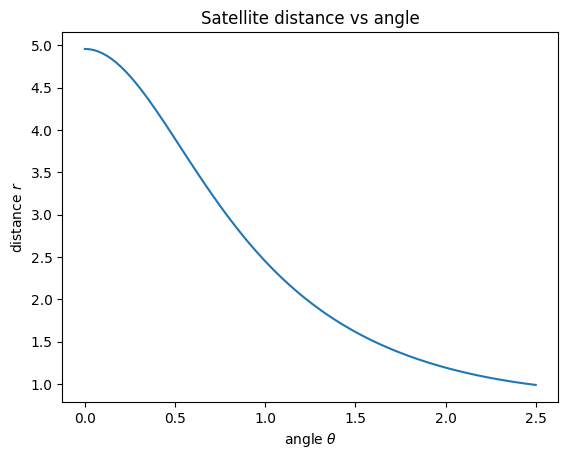

In [19]:
thetas = np.linspace(0, 2.5, 100)

r_theta = b_estimate / (1 - e_estimate * np.cos(thetas))

np.testing.assert_allclose(r_theta, np.array(state["r_theta_ans"])  , err_msg="r_theta is not correctly calculated")

plt.title("Satellite distance vs angle")
plt.plot(thetas, r_theta)
plt.xlabel("angle $\\theta$")
plt.ylabel("distance $r$")
plt.show()

Feel free to adjust the $b$ and $e$ values and noise values in the code below to see how it impacts $r(\theta)$.

In [20]:
def calculate_est(r, theta):
    coeff_ans = r * np.cos(theta)
    A_ans = np.array([[1.00, coeff_ans[0]],
                [1.00, coeff_ans[1]],
                [1.00, coeff_ans[2]],
                [1.00, coeff_ans[3]],
                [1.00, coeff_ans[4]]])

    C_ans = A_ans.T @ A_ans
    z_ans = A_ans.T @ r
    
    return np.linalg.solve(C_ans,z_ans)

def calculate_r_theta(theta, estimate):
    return estimate[0] / (1 - estimate[1] * np.cos(theta))

In [21]:
b = None
e = None
noise = np.random.normal(0,0.1,5)
r = np.array([3, 23/10, 33/20, 5/4, 101/100])

theta = noise + np.arccos((r - b)/(e*r))
estimate = calculate_est(r, theta)

thetas = np.linspace(0, 2.5, 100)
r_theta = calculate_r_theta(thetas, estimate)
r_theta_true = calculate_r_theta(thetas, [b,e])

plt.title("Satellite distance vs angle")
plt.plot(thetas, r_theta, label="Least squares estimates")
plt.plot(thetas, r_theta_true, label="True values")
plt.xlabel("angle $\\theta$")
plt.ylabel("distance $r$")
plt.legend()
plt.show()

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'